# The Multi-Needle Problem: Simultaneous Retrieval and Reasoning Fails to Scale

**Mehrab Modi** | April 2026 | [github.com/mehrabmodi1/agentic-retrieval](https://github.com/mehrabmodi1/agentic-retrieval)

Memory is at the core of who we are, how we think. Our ability to learn things, recall facts or reason about them is a complex series of discrete, cognitive operations we often take for granted. Over the last month or so, my work has involved building scaffolding for very capable coding agents to build high-quality code. For a coding-agent to work well, it too needs to retrieve facts from a large body of rememebered items (the code-base on disk) and then reason about them. This article is about an experiment I ran over the last week and a half, where I tried to systematically challenge agents over a range of retrieval and reasoning difficulties. And I found that even with Opus 4.6, in certain ranges of the difficulty parameter space, the agents mostly failed.  

The setup: I generated text corpora — some styled as Python repositories, others as noir detective fiction — and hid facts inside them. Then I asked a Claude Code agent to find those facts. Three flavours of task, each harder than the last. **Single-needle**: find one specific fact buried in the corpus. **Multi-chain**: follow a trail of cross-references across files to reach a final answer. **Multi-reasoning**: locate several scattered clues and piece them together to answer the question. I varied corpus size from 20k to 800k tokens, the number of items to find from 2 to 16, and how directly the question references the clues — from exact keyword matches to contextual paraphrases. 336 experimental conditions, each run 3 times. On top of that, I ran a smaller focused comparison — the same representative-parameter subset — with two alternative model-configurations: Sonnet 4.6 at effort=max (more test-time compute), and Opus 4.6 (Claude's strongest model) at effort=low.

Two headlines. The first: **more compute rescues chain-following, but not information-synthesis.** Sonnet 4.6 at effort=low reaches only ~60% on multi-chain; dial effort up to max and it climbs to ~100% — essentially matching Opus. For chain-following tasks, the agent just needed room to persist. Multi-reasoning tells a different story. When the agent has to find many items, hold them all in memory, and reason across them, neither increased compute nor model upgrade help: at n=16, every configuration I tried collapses to very low accuracy or completeness. This isn't a Sonnet problem or a low-effort problem. It looks like a general limitation of today's coding agents.

We are starting to give LLM-powered agents more agency in our world; from building code to planning itineraries. We should know the limits of their cognitive limitations. If simultaneous reasoning across ~8-16 retrieved facts is hard, we should design our code-bases or travel-criteria with that in mind. I know I would find such a task hard myself. But as models and agent harnesses race to get better, we can plan and design our systems to make the most of their capabilities. Token-maxing is a perverse metric after all. We should be maximising value/token first. The git repository I've shared with this article can be used to re-run these experiments, or even design new ones as agents get better and need harder challenges. I know I will keep returning to it (watch this space!) - and hope it provides value to others too.

A huge shoutout to Locus, my employer, for encouraging excitement about and experimentation with these ever-changing tools.

## What the tasks look like

To make this concrete, here are examples from each experiment type — one from the noir fiction corpus, one from the Python corpus.

**Single needle** — find one fact:
> *"According to Deke the bartender's witness statement, what location did the older man whisper to the kid at The Crimson Door Lounge?"* → **The Starlight Motor Inn, room 14**

> *"What is the value of `MAX_TASK_RETRY_DELAY` defined in this codebase?"* → **47**

**Multi-chain** — starting from a named location in the corpus, follow cross-references to reach a final answer. The question names the start of the chain, but not the intermediate steps — the agent has to discover those itself:
> *"Starting from the matchbook Catherine left with Eleanor Walsh, follow the chain to Deke at The Crimson Door. What address is written on the envelope Deke has been holding?"* → **Warehouse 9, Pier 41, north dock**
>
> Eleanor produces a matchbook from Catherine — it reads *The Crimson Door Lounge*. At The Crimson Door, the bartender Deke reveals a sealed envelope Catherine left with him. The address on it is the answer.

> *"Starting from `ROUTE_CHAIN_START` in `api/routes.md`, follow the chain of config references through each file. What is the final value that the chain ultimately resolves to?"* → **XK-7734-FINAL**
>
> The agent has to discover: `routes.md` points to `api/middleware.py` → `api/validators.py` → `api/pagination.py` → `api/serializers.py` → ... → `workers/email_worker.py` where the terminal value lives. Eight hops, each in a different file.

**Multi-reasoning** — find scattered clues across the corpus and synthesise them into a coherent answer. Unlike multi-chain, the agent can't follow a trail — it has to hold all the clues in memory and reason across them:
> *"Based on the evidence collected across the investigation, what time window was the crime committed in?"*
>
> Three facts are scattered across different files. A pharmacy receipt timestamped 8:47 PM confirms the victim was alive. A neighbour heard him until about 9:45 PM. The coroner's note says rigor onset suggests no more than four hours before the body was discovered at 11 PM. The agent has to find all three, recognise they constrain the same window, and conclude: **between 9:45 PM and 11:00 PM**.

> *"What is the total maximum memory allocation across all cache layers (`L1_CACHE_SIZE_MB`, `L2_CACHE_SIZE_MB`, `L3_CACHE_SIZE_MB`)?"*
>
> Each constant lives in a different config file. The agent has to find all three values (512, 2048, 8192) and sum them: **10,752 MB**.

In [1]:
BATCH_NAME = "full-sweep__20260408T130426"
WORKSPACE_DIR = "../workspace"

In [2]:
from pathlib import Path
from agent_retrieval.analysis.loader import load_batch_results
df = load_batch_results(BATCH_NAME, Path(WORKSPACE_DIR))

## Figure 0: Model and Effort Comparison

Before diving into the full parameter sweep, a headline comparison. I ran a focused subset of conditions (python repo, hard discriminability, synonym references) across four configurations:

- **Sonnet 4.6, effort=low** — the full sweep configuration
- **Sonnet 4.6, effort=max** — same model, maximum test-time compute
- **Opus 4.6, effort=low** — stronger model, same test-time compute setting
- **Opus 4.7, effort=low** — strongest available model, same test-time compute setting

The grid separates results by corpus size (rows: 40k vs 800k tokens) and number of items (columns: n=2 vs n=16). Single-needle appears only in the n=2 column as a baseline — it has no n-items dimension. Each column is a separate experimental corpus, and each dot, a repeat agent-run on it.

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import yaml as _yaml

sns.set_theme(style="white", font_scale=0.9)

# --- Figure 0: Model and Effort Comparison ---

COMPARISON_BATCHES = {
    "sonnet 4.6\neffort=low": "full-sweep__20260408T130426",
    "sonnet 4.6\neffort=max": "hard-synonym-subset_sonnet-4-6_effort-max__20260413T103017",
    "opus 4.6\neffort=low": "hard-synonym-subset_opus-4-6_effort-low__20260413T112314",
    "opus 4.7\neffort=low": "hard-synonym-subset_opus-4-7_effort-low__20260418T055310",
}

CONFIG_COLORS = {
    "sonnet 4.6\neffort=low": "#4F8BC4",
    "sonnet 4.6\neffort=max": "#D4956A",
    "opus 4.6\neffort=low": "#8868AE",
    "opus 4.7\neffort=low": "#5DB8A2",
}

CONFIG_SHORT = {
    "sonnet 4.6\neffort=low": "Sonnet 4.6\nlow",
    "sonnet 4.6\neffort=max": "Sonned 4.6\nmax",
    "opus 4.6\neffort=low": "Opus 4.6\nlow",
    "opus 4.7\neffort=low": "Opus 4.7\nlow",
}

CORPUS_SIZES = [40_000, 800_000]
CORPUS_LABELS = {40_000: "40k tokens", 800_000: "800k tokens"}

# Collect all individual scores into a tidy dataframe
rows = []
for config_label, batch_name in COMPARISON_BATCHES.items():
    jdir = Path(f"../workspace/judge/judgements/{batch_name}")
    for v in sorted(jdir.rglob("*.yaml")):
        data = _yaml.safe_load(v.read_text())
        pid = data["parametrisation_id"]

        if "python_repo" not in pid or "hard" not in pid or "synonym" not in pid:
            continue

        corpus_size = None
        if "40k" in pid:
            corpus_size = 40_000
        elif "800k" in pid:
            corpus_size = 800_000
        else:
            continue

        et = pid.split("__")[0]
        n_items = None
        if et in ("multi_chain", "multi_reasoning"):
            for part in pid.split("__"):
                if part.startswith("n") and part[1:].isdigit():
                    n_items = int(part[1:])
            if n_items not in (2, 16):
                continue

        rows.append({
            "config": config_label,
            "experiment_type": et,
            "n_items": n_items,
            "corpus_size": corpus_size,
            "score": data["weighted_score"],
        })

fig0_df = pd.DataFrame(rows)

exp_label_map = {
    "single_needle":   "single needle",
    "multi_chain":     "multi-chain",
    "multi_reasoning": "multi-reasoning",
}
config_labels = list(COMPARISON_BATCHES.keys())
n_configs = len(config_labels)
group_spacing = 0.18   # offset between configs within a group
group_gap = 1.0        # distance between experiment-type groups
dot_size = 120
jitter_width = 0.04

fig0, axes0 = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

for row_idx, corpus_size in enumerate(CORPUS_SIZES):
    for col_idx, n_val in enumerate([2, 16]):
        ax = axes0[row_idx, col_idx]
        panel_exp_types = (
            ["single_needle", "multi_chain", "multi_reasoning"] if col_idx == 0
            else ["multi_chain", "multi_reasoning"]
        )
        n_groups = len(panel_exp_types)

        sub = fig0_df[fig0_df["corpus_size"] == corpus_size]
        if col_idx == 0:
            sub = sub[(sub["n_items"].isna()) | (sub["n_items"] == n_val)]
        else:
            sub = sub[sub["n_items"] == n_val]
        sub = sub[sub["experiment_type"].isin(panel_exp_types)]

        # Compute x positions: each group centred at group_idx * group_gap
        # configs within group spread symmetrically
        group_centers = {et: i * group_gap for i, et in enumerate(panel_exp_types)}
        config_offsets = {
            cfg: (ci - (n_configs - 1) / 2) * group_spacing
            for ci, cfg in enumerate(config_labels)
        }

        tick_positions = []
        tick_labels = []

        for ci, config_label in enumerate(config_labels):
            cfg_sub = sub[sub["config"] == config_label]
            np.random.seed(ci)
            for _, row_data in cfg_sub.iterrows():
                et = row_data["experiment_type"]
                xpos = group_centers[et] + config_offsets[config_label]
                jitter = np.random.uniform(-jitter_width / 2, jitter_width / 2)
                ax.scatter(
                    xpos + jitter, row_data["score"],
                    color=CONFIG_COLORS[config_label],
                    s=dot_size, alpha=0.85, zorder=3,
                )

        # x-ticks: one per config per group, labelled with short config name
        for et in panel_exp_types:
            gc = group_centers[et]
            for ci, cfg in enumerate(config_labels):
                xpos = gc + config_offsets[cfg]
                tick_positions.append(xpos)
                tick_labels.append(CONFIG_SHORT[cfg])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha="right")

        # Group labels (experiment type) above the tick area
        for et in panel_exp_types:
            gc = group_centers[et]
            ax.text(gc, -0.17, exp_label_map[et], ha="center", va="top",
                    fontsize=9, fontweight="bold", transform=ax.get_xaxis_transform())

        # Vertical separators between groups
        for i in range(1, n_groups):
            sep = (group_centers[panel_exp_types[i-1]] + group_centers[panel_exp_types[i]]) / 2
            ax.axvline(sep, color="0.85", linewidth=0.8, zorder=0)

        ax.set_xlim(
            group_centers[panel_exp_types[0]] - 0.5,
            group_centers[panel_exp_types[-1]] + 0.5,
        )
        ax.set_ylim(-0.05, 1.15)
        ax.set_title(f"{CORPUS_LABELS[corpus_size]} — n = {n_val} items", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("weighted score" if col_idx == 0 else "")
        sns.despine(ax=ax)

# Legend (colour = config)
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CONFIG_COLORS[cfg],
           markersize=10, label=cfg.replace("\n", " "))
    for cfg in config_labels
]
axes0[0, 0].legend(handles=handles, fontsize=8, loc="lower right", frameon=False)

fig0.suptitle("Figure 0: Model and Effort Comparison (hard / synonym / python repo)", fontsize=13, fontweight="bold", y=1.01)
fig0.tight_layout()
plt.show()

At n=2, the task should be tractable — find two facts, chain them or sum them, report the answer. In the 40k corpus, that is broadly what happens: most configurations score high, and the spread across models and effort settings is modest. In the 800k corpus, the picture starts to change. Two configurations — Sonnet 4.6 at effort=low and Opus 4.7 at effort=low — collapse to zero across all three runs on the multi-chain task, while Sonnet at effort=max and Opus 4.6 continue to succeed. These failures were mostly hallucinations. Interesting that Opus 4.7 was more prone to it than 4.6, both at effort mode low. The larger corpus-size prompted these agents to make up answers rather than honestly fail.

The right column, n=16, tells a starker story. Multi-reasoning at high item counts fails across every configuration in both corpus sizes — this is the core finding of the experiment, and it holds without exception. But corpus size is not irrelevant even here. Scores at 800k are noticeably lower than at 40k for the failing configurations, and the already-sparse successes at 40k become rarer still at 800k. When the agent must simultaneously track sixteen scattered facts through a large codebase, the retrieval problem and the reasoning problem compound each other: more background noise makes each individual fact harder to locate, and the working-memory demand of holding all sixteen in relation to each other remains just as high. Neither model scale nor increased compute resolves this. The wall is consistent, but the corpus makes it slightly higher.

## Claude Sonnet 4.6, effort = Low, large parameter sweep 

The rest of the data analyses where the reference model configuration does well or does poorly in a large range of parameters that affect retrieval and/or cognitive difficulty.

## Figure 1: Accuracy and Completeness vs Corpus Size

**(a, b)** Mean correctness (solid) vs completeness (dashed) by corpus size, for python repo and noir fiction.
**(c, d)** Weighted correctness and completeness score by reference clarity (exact / synonym / contextual). Low-opacity lines show individual clarity levels; bold lines show the mean.
**(e, f)** Weighted score by number of items to find (multi-chain and multi-reasoning only).

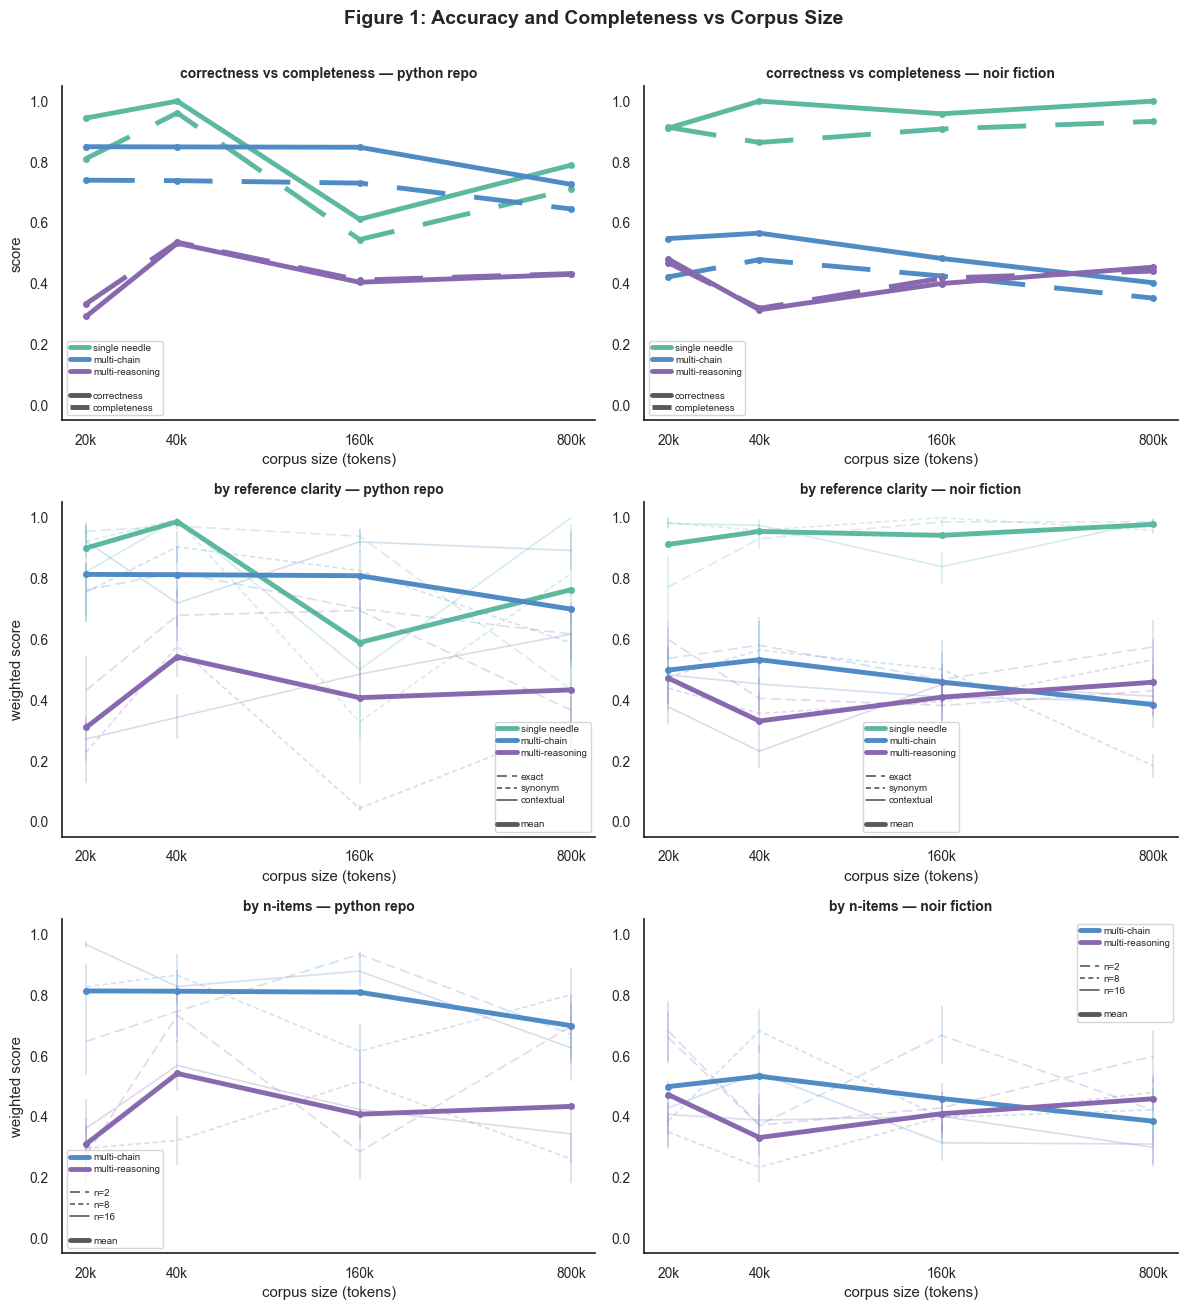

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="white", font_scale=0.9)

EXP_ORDER = ["single_needle", "multi_chain", "multi_reasoning"]
EXP_LABELS = {"single_needle": "single needle", "multi_chain": "multi-chain", "multi_reasoning": "multi-reasoning"}
PROFILES = ["python_repo", "noir_fiction"]
PROFILE_LABELS = {"noir_fiction": "noir fiction", "python_repo": "python repo"}
CLARITY_ORDER = ["exact", "synonym", "contextual"]
N_ITEMS_ORDER = [2, 8, 16]

# Cohesive teal → blue → purple (light → dark ≈ easy → hard task)
EXP_PALETTE = {"single_needle": "#5DB8A2", "multi_chain": "#4F8BC4", "multi_reasoning": "#8868AE"}

# Warm earth/amber palette for tools (distinct from cool experiment colours)
TOOL_PALETTE = ["#E07B54", "#5BA37C", "#4A90C4", "#C4A24E", "#A0A0A0"]  # grep, glob, read, subagent, other

CLARITY_DASHES = {"exact": (6, 3), "synonym": (3, 2), "contextual": ""}
NITEMS_DASHES = {2: (6, 3), 8: (3, 2), 16: ""}

DETAIL_ALPHA = 0.25
MEAN_ALPHA = 1.0
MEAN_LW = 3.5
DETAIL_LW = 1.2

CORPUS_SIZES = [20_000, 40_000, 160_000, 800_000]
CORPUS_LABELS = ["20k", "40k", "160k", "800k"]

def set_corpus_xticks(ax):
    ax.set_xscale("log")
    ax.set_xticks(CORPUS_SIZES)
    ax.set_xticklabels(CORPUS_LABELS)
    ax.xaxis.set_minor_locator(mticker.NullLocator())

def _dash_kwargs(dash):
    """Return linestyle/dashes kwargs, avoiding passing None to matplotlib."""
    if dash:
        return {"linestyle": "--", "dashes": dash}
    return {"linestyle": "-"}

def add_legend(ax, mode="clarity"):
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER if mode == "clarity" or e in ["multi_chain", "multi_reasoning"]
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    if mode == "clarity":
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=c, **_dash_kwargs(CLARITY_DASHES[c]))
            for c in CLARITY_ORDER
        ]
    else:
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=f"n={n}", **_dash_kwargs(NITEMS_DASHES[n]))
            for n in N_ITEMS_ORDER
        ]
    mean_handle = mlines.Line2D([], [], color="0.35", linewidth=3.5, linestyle="-", label="mean")
    all_handles = type_handles + [spacer] + series_handles + [spacer, mean_handle]
    ax.legend(handles=all_handles, fontsize=7, loc="best", ncol=1,
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

def plot_series(ax, df, y_col, exp_types, mode="clarity"):
    items = CLARITY_ORDER if mode == "clarity" else N_ITEMS_ORDER
    dashes = CLARITY_DASHES if mode == "clarity" else NITEMS_DASHES
    group_col = "reference_clarity" if mode == "clarity" else "n_items"

    for exp_type in exp_types:
        color = EXP_PALETTE[exp_type]
        sub_all = df[df["experiment_type"] == exp_type]
        if mode == "nitems":
            sub_all = sub_all.dropna(subset=["n_items"])
        if sub_all.empty:
            continue

        for item in items:
            isub = sub_all[sub_all[group_col] == item]
            if isub.empty:
                continue
            stats = isub.groupby("corpus_token_count")[y_col].agg(["mean", "std", "count"]).reset_index()
            stats["sem"] = stats["std"] / np.sqrt(stats["count"])
            ax.errorbar(
                stats["corpus_token_count"], stats["mean"], yerr=stats["sem"].fillna(0),
                color=color, linewidth=DETAIL_LW, capsize=0, markersize=0,
                alpha=DETAIL_ALPHA, **_dash_kwargs(dashes[item]),
            )

        mean_stats = sub_all.groupby("corpus_token_count")[y_col].agg(["mean"]).reset_index()
        ax.plot(
            mean_stats["corpus_token_count"], mean_stats["mean"],
            color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
        )

# --- Figure 1: Accuracy and Completeness vs Corpus Size (3x2) ---
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# Row 1: correctness vs completeness (mean only, all experiment types)
SCORE_DASHES = {"correctness": "", "completeness": (10, 6)}
for col_idx, profile in enumerate(PROFILES):
    ax = axes[0, col_idx]
    sub = df[df["content_profile"] == profile]
    for exp_type in EXP_ORDER:
        color = EXP_PALETTE[exp_type]
        esub = sub[sub["experiment_type"] == exp_type]
        if esub.empty:
            continue
        for metric, dash in SCORE_DASHES.items():
            col = f"score_{metric}"
            if col not in esub.columns:
                continue
            stats = esub.dropna(subset=[col]).groupby("corpus_token_count")[col].mean().reset_index()
            ax.plot(
                stats["corpus_token_count"], stats[col],
                color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
                **_dash_kwargs(dash),
            )
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"correctness vs completeness — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("score")
    ax.set_xlabel("corpus size (tokens)")
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    metric_handles = [
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="-", label="correctness"),
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="--", dashes=(10, 6), label="completeness"),
    ]
    ax.legend(handles=type_handles + [spacer] + metric_handles, fontsize=7, loc="best",
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)
    sns.despine(ax=ax)

# Row 2: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", EXP_ORDER, mode="clarity")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 3: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes[2, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", ["multi_chain", "multi_reasoning"], mode="nitems")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig.suptitle("Figure 1: Accuracy and Completeness vs Corpus Size", fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

Each run is scored on two criteria: *correctness* — whether the agent's final answer matches the ground truth — and *completeness* — whether it found and cited all the required source locations along the way. I computed a weighted score where correctness is weighted twice as heavily, reflecting the primacy of getting the right answer. In the first two plots, the two scores track each other closely throughout: agents that find the right answer almost always cite the right sources, and those that miss the answer tend to miss the sources too. Where the two diverge, completeness is consistently the lower of the pair — the agent synthesised a correct answer but skipped or missed some of the intermediate steps it took to get there.

The most striking result in the first two panels is by corpus type. Python repository corpora yield consistently higher scores than noir fiction on the multi-needle chain task. A Python codebase has a rigid, navigable structure — file names, function signatures, and import chains give the agent reliable footholds for following a reference trail. Noir fiction demands interpretation: the clues are embedded in prose, and the agent must read for meaning rather than scan for syntax.

For the rest of the figures, I've plotted the weighted, combined score. Reference directness, shown in the middle panels, has a small but systematic effect. Questions that name the target exactly tend to score highest; contextual paraphrases score lowest; synonyms fall in between. But the spread across clarity levels rarely exceeds ten percentage points for any given experiment type and corpus size. Within the conditions tested here, the agent is reasonably robust to surface-level paraphrase — it finds what you mean, not just what you say.

The n-items panels tell the most consequential story. For multi-chain, performance holds up reasonably at n=2 and n=8 before falling sharply at n=16 — the agent can follow a trail, but struggles when it gets too long, especially in a large, background corpus. For the multi-reasoning experiment, where simultaneous reasoning over n-items is needed, the degradation is more severe. 

One feature of these panels is curious: the n=2 line is not uniformly the highest. At the smallest corpus size (20k tokens) under hard discriminability, the agent systematically scored zero — not because it partially succeeded, but because it repeatedly hallucinated that the target values were absent from the codebase entirely. There was an interesting observation involving hallucination in figure 0 too. An interesting follow-up might be to look at when agents choose to hallucinate - especially when effort-mode is set to low.

## Figure 2: Answering-Session Cost vs Corpus Size

Y-axis shows total session cost in USD as reported by the Claude Agent SDK, including subagent token spend. This cost correlates with the number of tokens the agent has in-context.

**(a, b)** Session cost by reference clarity.
**(c, d)** Session cost by number of items.

Mean-lines are identical. 

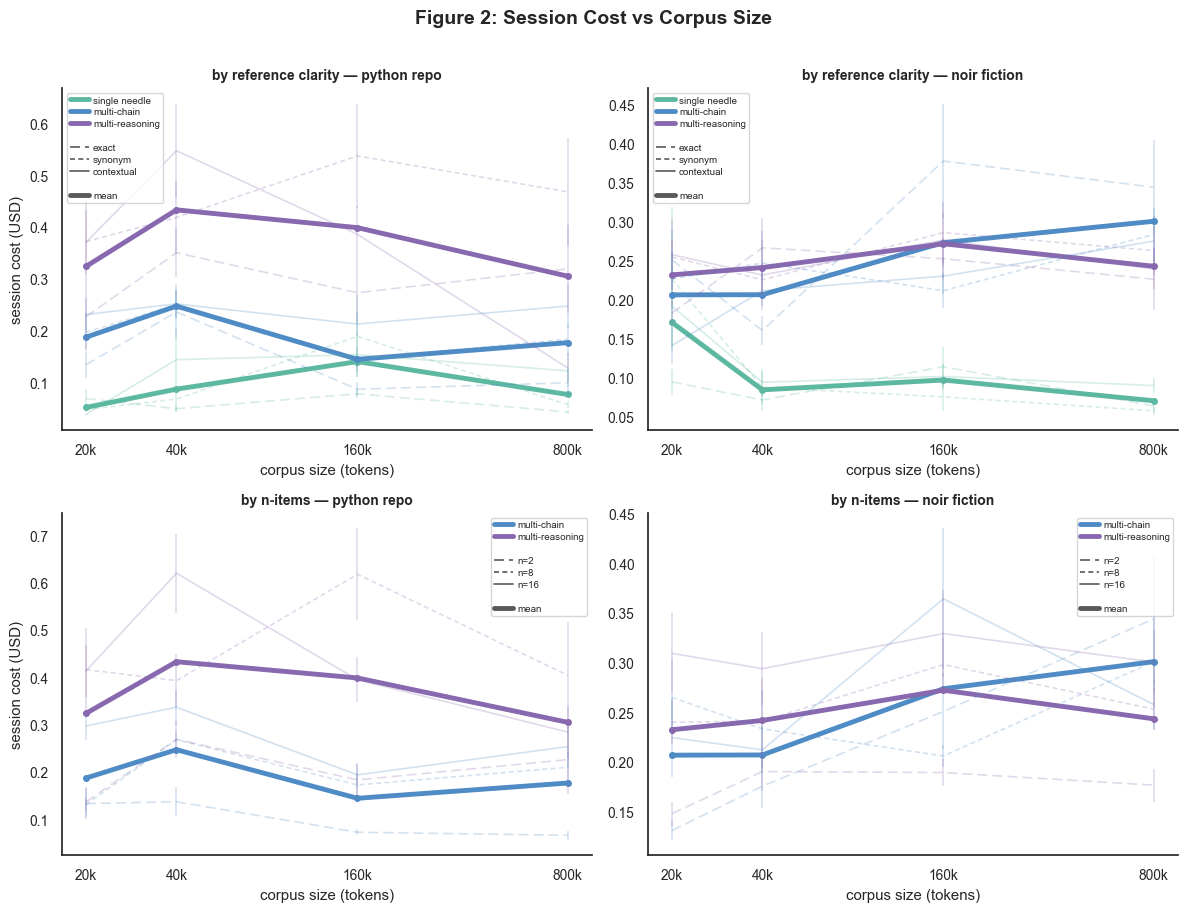

In [6]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 2: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig2.suptitle("Figure 2: Session Cost vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig2.tight_layout()
plt.show()

The most immediate observation here is what is *not* visible: For the detective novel corpuses, token cost scales marginally with corpus size. For the python repository corpuses, there is almost no scaling at all! It looks like the known structure of python code is leveraged by the model to pick out clues however large the background. Also, session cost is largely insensitive to both reference clarity and number of items.

What we do see is that the multi-reasoning sessions are consistently the most expensive, reflecting the wider search required when clues are scattered rather than chained and need simultaneous reasoning. But within a given experiment type and corpus size, the variance across runs appears to be dominated by the choices each agent instance makes on its exploratory path rather than by the structural properties of the task. Different runs of the same condition can produce very different tool-call sequences.

There is a subtler point here too. This sweep was run with effort set to low, which instructs the agent to be economical with compute. The flat cost profile across difficulty levels may partly reflect the agent honouring that setting: rather than persisting longer on hard problems, it commits to a search path and stops — which would explain why harder conditions cost no more but score less. In that reading, the accuracy drop we see across conditions in Figure 1 is not purely a capability failure. Some portion of it may be the agent making an economical choice to stop searching, consistent with its effort budget.

## Figure 3: Tool Breakdown by Experiment Type

Percentage of tool calls by category for each experiment type. Subagent calls are opaque — each may trigger many internal tool calls not visible here.

*Single panel.* grep / glob / read / subagent / other.

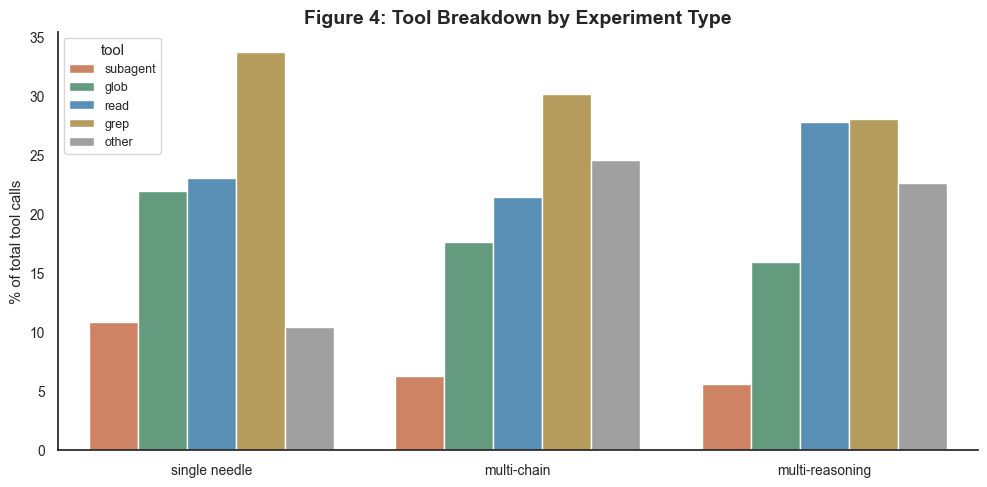

In [7]:
import pandas as pd

tool_cols = [c for c in df.columns if c.startswith("tool_")]
tool_names = [c.replace("tool_", "") for c in tool_cols]

tool_data = []
for exp_type in EXP_ORDER:
    sub = df[df["experiment_type"] == exp_type]
    means = {tn: sub[tc].mean() for tc, tn in zip(tool_cols, tool_names) if not np.isnan(sub[tc].mean())}
    total = sum(means.values())
    if total > 0:
        for tn, mean_val in means.items():
            tool_data.append({
                "experiment type": EXP_LABELS[exp_type],
                "tool": tn,
                "% of total calls": mean_val / total * 100,
            })

tool_df = pd.DataFrame(tool_data)

fig4, ax4 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tool_df, x="experiment type", y="% of total calls", hue="tool",
    palette=TOOL_PALETTE, ax=ax4,
)
ax4.set_title("Figure 4: Tool Breakdown by Experiment Type", fontsize=14, fontweight="bold")
ax4.legend(title="tool", fontsize=9)
ax4.set_xlabel("")
ax4.set_ylabel("% of total tool calls")
sns.despine(ax=ax4)
fig4.tight_layout()
plt.show()

Across all three experiment types, grep is the dominant tool — which is exactly what you would expect from an information-retrieval task. The agent's primary strategy is to search: find the file that contains the answer, then extract the relevant value. What is more interesting is the shift in the balance between grep and read as task type changes. For single-needle and multi-chain tasks, greps substantially outnumber file reads, consistent with a targeted search-then-confirm workflow. In multi-reasoning, that gap narrows considerably: reads are essentially as frequent as greps.

This shift is could reflect cognitive load rather than search strategy. When the agent needs to find scattered clues and hold them in relation to each other, a grep that surfaces a line of code may not be sufficient — the surrounding context matters for understanding whether a value is the right one, how it relates to other values, and whether the chain of reasoning holds together.

## Conclusions

The results across these figures converge on a small number of findings that are robust enough to act on.

The most important is the sharpest: **information synthesis at scale is broken, and it stays broken regardless of what you do to the model.** When a coding agent must find sixteen scattered facts and reason across all of them simultaneously, every configuration tested — from Sonnet 4.6 at low effort to Opus 4.7 — fails. This is not a model generation problem, and it is not a compute problem. More test-time compute rescues chain-following, where the agent just needs to persist longer along a well-defined trail. It does not rescue synthesis, where the bottleneck appears to be something more like working memory: the agent cannot reliably hold many retrieved facts in relation to each other while still searching for more. The boundary sits somewhere between n=8 and n=16 for the conditions tested here, and it sits lower for multi-reasoning than for multi-chain. One could analyse the graph structure of code-bases or any knowledge-base to predict where agents might work or might not. A code-base with a dependency-graph that looks like a hairball (> 8-16 dependencies are common), would be hard for agents to work with. A code-base with a clean, modular dependency-graph would be easier. Design carefully!

The second finding is subtler but practically important: **effort=low interacts badly with large corpora, even when the task is simple.** At 800k tokens, agents running at low effort — including Opus 4.7 — did not just score poorly on the multi-chain n=2 task. They hallucinated. They reported that the relevant files did not exist, rather than searching more thoroughly or acknowledging uncertainty. This is a failure mode that is invisible in aggregate metrics but dangerous in practice: a wrong confident answer is worse than no answer. Corpus size, in other words, is not just a retrieval difficulty parameter — it is a hallucination risk parameter when effort is constrained. On the flip-side, increasing effort budget for a smaller model made it as good as the larger model, at least in the long, multi-needle chain task.

A third, more encouraging finding is that the structural properties of the codebase itself are not irrelevant: Python repositories consistently outperformed noir fiction prose, and the effect was largest for chain-following tasks. Structure helps. The agent finds it easier to navigate a codebase that is already organised around explicit cross-references — import chains, function signatures, documented trails — than one where the relevant information is embedded in continuous text.

We are in a world where agentic tools are becoming widely used, and models keep getting better. We should keep in mind the dependency structures of our systems - code-bases, business SOPs, or any sufficiently complex body of text. And we should keep re-measuring agent capabilities, as models and harnesses get better and better! For now, Opus 4.7 doesn't look like a huge step up from 4.6 when it comes to simultaneous retrieval and reasoning. But I plan to keep tweaking the experiment, and running the model. Watch this space!